In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("creditcard.csv")

print(df.shape)
print(df['Class'].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_bal))

Before SMOTE: [227451    394]
After SMOTE: [227451 227451]


In [10]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [27]:
import torch
import torch.nn as nn

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train_bal, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_bal.values, dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).to(device)

In [31]:
class TabularTransformer(nn.Module):
    def __init__(self, input_dim):
        super(TabularTransformer, self).__init__()

        self.embedding = nn.Linear(input_dim, 64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.unsqueeze(1)  # Add sequence dimension
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

In [32]:
from torch.utils.data import DataLoader, TensorDataset

In [33]:
model = TabularTransformer(input_dim=X_train.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

In [41]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb).squeeze()
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 53.7499
Epoch 2, Loss: 16.2501
Epoch 3, Loss: 11.5489
Epoch 4, Loss: 10.4725
Epoch 5, Loss: 9.6534
Epoch 6, Loss: 8.4843
Epoch 7, Loss: 8.3247
Epoch 8, Loss: 7.3957
Epoch 9, Loss: 7.6749
Epoch 10, Loss: 7.2451


In [42]:
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor).squeeze()
    probs = torch.sigmoid(logits).cpu().numpy()

preds = (probs > 0.9).astype(int)

print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.87      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9636662627909915


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Basic metrics
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)
roc_auc = roc_auc_score(y_test, probs)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
print("\nConfusion Matrix:\n", cm)

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy: 0.9989466661985184
Precision: 0.6439393939393939
Recall: 0.8673469387755102
F1-Score: 0.7391304347826086
ROC-AUC: 0.9636662627909915

Confusion Matrix:
 [[56817    47]
 [   13    85]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.87      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962



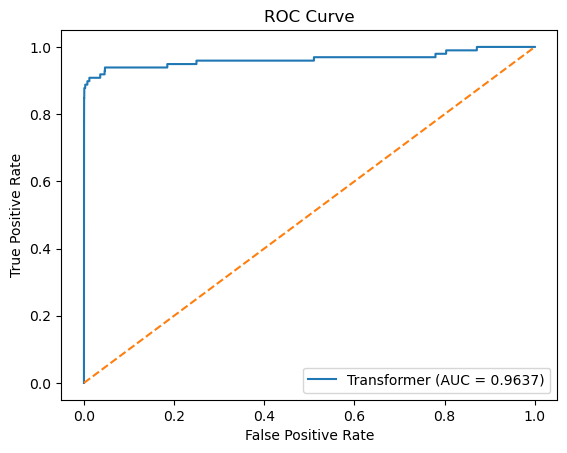

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr, label="Transformer (AUC = %0.4f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

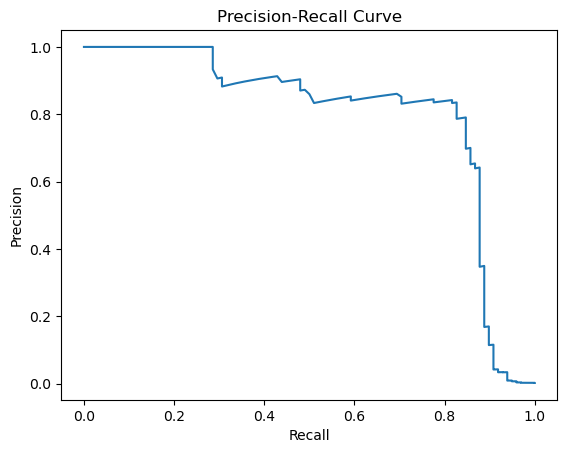

In [46]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, probs)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()